# CMPT 742 - Fall 2026
# Assignment 1, Part 2: Poisson blending (tutorial)

__content creator:__ Yalda

This notebook walks through the ideas you need for Part 2 using small toy examples.

1. The idea
2. Blending in 1D
3. Numbering only the masked pixels
4. Blending a 5×5 image
5. The trap: where the guidance comes from
6. Notes for the assignment

We only use **numpy** and **matplotlib**.

### How this notebook works
You write most of the code yourself. Each **TODO** has:
1. a cell for **your code**: replace the `...`,
2. a hidden **Solution** cell right below it. Try it yourself first!
3. a cell that **checks** your answer: look for `correct: True`.

Run the cells in order. If you get stuck, run the Solution cell and move on.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=2, suppress=True)   # print numbers with 2 decimals

### Plot helpers
Run this cell. It defines two small functions that draw our plots **with the numbers written on them** and a grid,
so you can read every value. You don't need to change it.

In [2]:
def number_text(x):
    """Short text for a number: 3.0 -> '3', 0.25 -> '0.25', -0.0000001 -> '0'."""
    x = round(float(x), 2) + 0.0      # + 0.0 turns -0.0 into 0.0
    return f'{x:g}'


def plot_1d(signals, labels, title):
    """Plot 1D signals with every value written on its point, whole-number ticks and a grid."""
    plt.figure(figsize=(8, 4))
    for values, label in zip(signals, labels):
        line = plt.plot(values, 'o-', label=label)[0]
        for i in range(len(values)):
            plt.text(i, values[i] + 0.3, number_text(values[i]), color=line.get_color(), ha='center')
    all_values = np.concatenate(signals)
    plt.xticks(range(len(signals[0])))
    plt.yticks(range(int(np.floor(all_values.min())) - 1, int(np.ceil(all_values.max())) + 2))
    plt.grid(True)
    plt.xlabel('position i')
    plt.ylabel('value')
    plt.title(title)
    plt.legend()
    plt.show()


def show_image(ax, img, title, vmin=0, vmax=1, cmap='gray', write_values=True, hide_zeros=False):
    """Show a small image with its value written on every pixel and a grid between pixels."""
    h, w = img.shape
    ax.imshow(img, cmap=cmap, vmin=vmin, vmax=vmax)
    ax.set_title(title)
    ax.set_xticks(range(w))           # column numbers
    ax.set_yticks(range(h))           # row numbers
    ax.set_xticks(np.arange(-0.5, w), minor=True)
    ax.set_yticks(np.arange(-0.5, h), minor=True)
    ax.grid(which='minor', color='gray', linewidth=1)
    ax.tick_params(which='minor', length=0)
    if write_values:
        for i in range(h):
            for j in range(w):
                if hide_zeros and img[i, j] == 0:
                    continue
                dark_pixel = cmap == 'gray' and img[i, j] < (vmin + vmax) / 2
                ax.text(j, i, number_text(img[i, j]), ha='center', va='center',
                        color='white' if dark_pixel else 'black')

# 1. The idea

We want to paste a piece of a **source** image into a **target** image, without a visible seam.

- A **naive paste** just copies the source pixels. The colours don't match, so you see the border.
- **Poisson blending** keeps the **details** (the second derivatives, the "bends") of the source,
  but makes the border match the target. The colours of the patch adjust smoothly.

It is the same tool as Part 1, with a few changes:

| | Part 1: reconstruction | Part 2: Poisson blending |
|---|---|---|
| Unknowns | every pixel | only the pixels **inside the mask** |
| Second derivatives come from | the image S | the **source** image |
| Fixed (known) values | the 4 corners | the **target** pixels just outside the mask |
| Pixels outside the mask | (none) | stay the target, unchanged |

# 2. Blending in 1D

A target signal (a straight slope) and a source signal (flat with a bump).
We want to paste positions **2 to 5** of the source into the target. These positions are our **mask**.

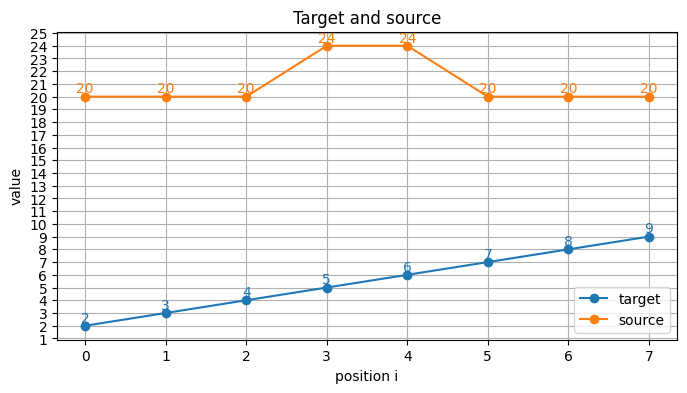

In [3]:
tgt1 = np.array([2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0])
src1 = np.array([20.0, 20.0, 20.0, 24.0, 24.0, 20.0, 20.0, 20.0])

plot_1d([tgt1, src1], ['target', 'source'], 'Target and source')

### Step 1: naive paste
Copy the source values at positions 2 to 5 into a copy of the target.

In [ ]:
naive1 = tgt1.copy()

# TODO: copy the source values at positions 2 to 5 into naive1
...

#### Solution
Try it yourself first, then open the hidden cell below.

In [4]:
#@title Solution
naive1 = tgt1.copy()
naive1[2:6] = src1[2:6]

naive1 = [ 2.  3. 20. 24. 24. 20.  8.  9.]
correct: True


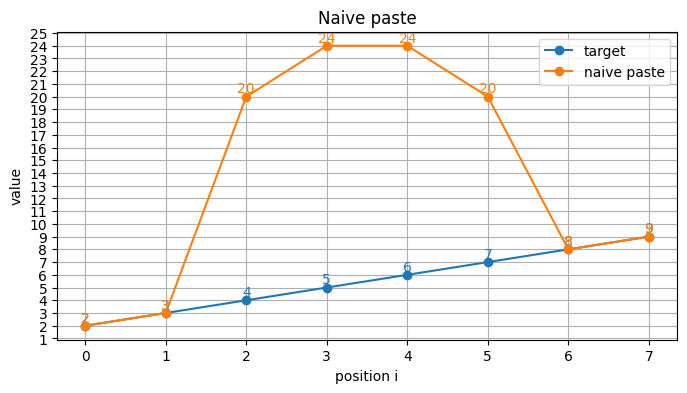

In [6]:
# run this cell to check your code
print('naive1 =', naive1)
print('correct:', np.allclose(naive1, [2, 3, 20, 24, 24, 20, 8, 9]))

plot_1d([tgt1, naive1], ['target', 'naive paste'], 'Naive paste')

See the big jumps between positions 1 → 2 and 5 → 6? That's the visible **seam**.

### Step 2: compute b

The mask has 4 positions, so we have **4 unknowns**: position `i` is unknown number `k = i - 2`.

For each position `i` inside the mask, we want the **same bend as the source**:

$$2v[i] - v[i-1] - v[i+1] = 2\,src[i] - src[i-1] - src[i+1]$$

At position 2, the left neighbour `v[1]` is **outside** the mask. It's not an unknown: it stays the target value `tgt1[1]`.
So we move it to the right side:

$$2v[2] - v[3] = (2\,src[2] - src[1] - src[3]) + tgt1[1]$$

The same happens at position 5 with its right neighbour `tgt1[6]`.

In [ ]:
b1 = np.zeros(4)

for i in range(2, 6):
    k = i - 2
    # TODO: the second derivative of the source at position i
    ...

# TODO: the two neighbours outside the mask are target pixels: add their values to b1
...

#### Solution
Try it yourself first, then open the hidden cell below.

In [7]:
#@title Solution
b1 = np.zeros(4)

for i in range(2, 6):
    k = i - 2
    b1[k] = 2 * src1[i] - src1[i - 1] - src1[i + 1]

b1[0] += tgt1[1]                     # left neighbour of position 2 is outside the mask
b1[3] += tgt1[6]                     # right neighbour of position 5 is outside the mask

In [8]:
# run this cell to check your code
print('b1 =', b1)
print('correct:', np.allclose(b1, [-1, 4, 4, 4]))

b1 = [-1.  4.  4.  4.]
correct: True


### Step 3: build A

Row `k` is the equation for unknown `k`: `2` on the diagonal, and `-1` for each neighbour that is **inside** the mask.
Neighbours outside the mask are not in A (they went to b).

In [ ]:
A1 = np.zeros((4, 4))

# TODO: fill A1
...

#### Solution
Try it yourself first, then open the hidden cell below.

In [19]:
#@title Solution
A1 = np.zeros((4, 4))

for k in range(4):
    A1[k, k] = 2
    if k > 0:                        # left neighbour is inside the mask
        A1[k, k - 1] = -1
    if k < 3:                        # right neighbour is inside the mask
        A1[k, k + 1] = -1

In [20]:
# run this cell to check your code
print(A1)
print('correct:', np.allclose(np.diag(A1), 2) and np.count_nonzero(A1) == 10
      and np.allclose(A1, A1.T) and np.allclose(A1.sum(axis=1), [1, 0, 0, 1]))

[[ 2. -1.  0.  0.]
 [-1.  2. -1.  0.]
 [ 0. -1.  2. -1.]
 [ 0.  0. -1.  2.]]
correct: True


### Step 4: solve and put the result back

Solve for the 4 unknowns, then put them into a copy of the target at positions 2 to 5.

In [ ]:
# TODO: solve A1 v1 = b1
v1 = ...

# TODO: put v1 into a copy of the target at positions 2 to 5
blended1 = ...

#### Solution
Try it yourself first, then open the hidden cell below.

In [21]:
#@title Solution
v1 = np.linalg.solve(A1, b1)

blended1 = tgt1.copy()
blended1[2:6] = v1

blended1 = [ 2.  3.  4.  9. 10.  7.  8.  9.]
correct: True
bends of the source inside the mask:  [-4.  4.  4. -4.]
bends of the result inside the mask:  [-4.  4.  4. -4.]


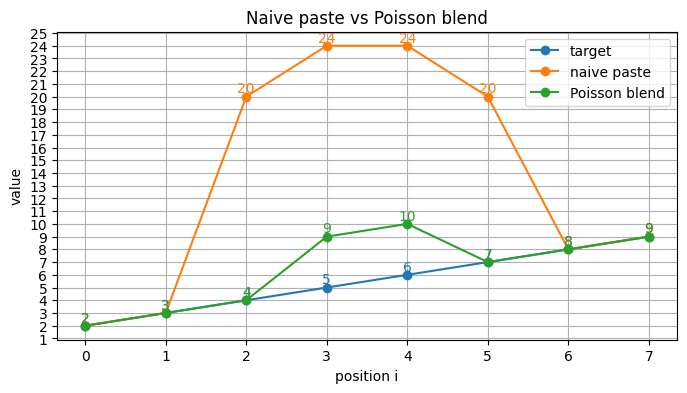

In [22]:
# run this cell to check your code
print('blended1 =', blended1)
print('correct:', np.allclose(blended1, [2, 3, 4, 9, 10, 7, 8, 9]))

print('bends of the source inside the mask: ', np.array([2 * src1[i] - src1[i - 1] - src1[i + 1] for i in range(2, 6)]))
print('bends of the result inside the mask: ', np.array([2 * blended1[i] - blended1[i - 1] - blended1[i + 1] for i in range(2, 6)]))

plot_1d([tgt1, naive1, blended1], ['target', 'naive paste', 'Poisson blend'], 'Naive paste vs Poisson blend')

No more jumps! The result follows the target's slope, and the **bump of the source (+4) is kept on top of it**.
The bends inside the mask are the same as the source's: only the overall level changed.

# 3. Numbering only the masked pixels

In 2D, the unknowns are only the pixels **inside the mask**. In Part 1 every pixel had a number `k = i * w + j`,
but now we need a number only for the masked pixels: 0, 1, 2, ... in order, row by row.

Here is a 5×5 image with a **plus-shaped** mask (1 = inside the mask):

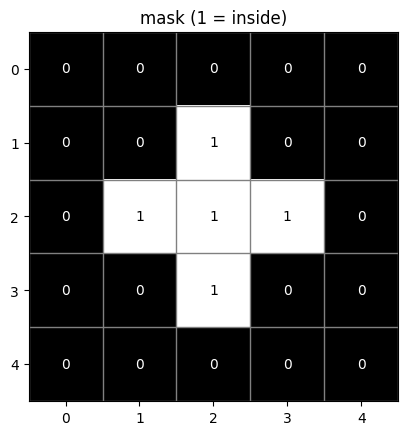

In [30]:
h, w = 5, 5
mask = np.zeros((h, w))
mask[1, 2] = 1
mask[2, 1] = 1
mask[2, 2] = 1
mask[2, 3] = 1
mask[3, 2] = 1

fig, ax = plt.subplots()
show_image(ax, mask, 'mask (1 = inside)')
plt.show()

Make an array `unknown_index` with the same shape as the image:
- for a pixel inside the mask: its unknown number (0, 1, 2, ...), counting row by row,
- for a pixel outside the mask: `-1`.

In [14]:
unknown_index = np.full((h, w), -1)  # -1 = not an unknown
count = 0

for i in range(h):
    for j in range(w):
        # TODO: if (i, j) is inside the mask, give it the next number
        ...

#### Solution
Try it yourself first, then open the hidden cell below.

In [27]:
#@title Solution
unknown_index = np.full((h, w), -1)  # -1 = not an unknown
count = 0

for i in range(h):
    for j in range(w):
        if mask[i, j] == 1:
            unknown_index[i, j] = count
            count = count + 1

number of unknowns: 5
correct: True


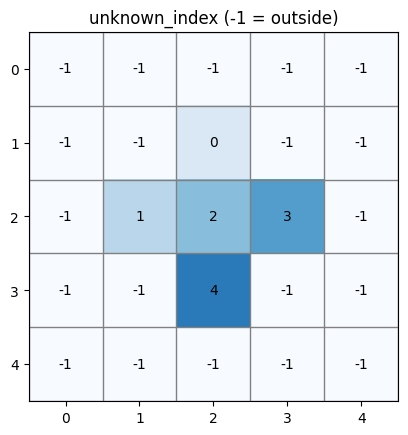

In [28]:
# run this cell to check your code
print('number of unknowns:', count)
print('correct:', count == 5 and unknown_index[2, 2] == 2 and np.sum(unknown_index == -1) == 20)

fig, ax = plt.subplots()
show_image(ax, unknown_index, 'unknown_index (-1 = outside)', vmin=-1, vmax=6, cmap='Blues')
plt.show()

This is the same order as `image[mask == 1]` (row by row). We'll use that to put the result back into the image.

# 4. Blending a 5×5 image

- **Target:** a smooth dark ramp (darker on the left).
- **Source:** bright (0.8) with one brighter dot (1.0) in the middle. The dot is the "detail" we want to keep.

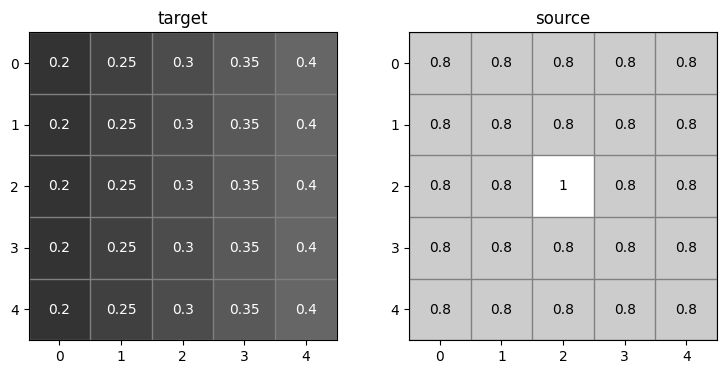

In [29]:
tgt2 = np.zeros((h, w))
for j in range(w):
    tgt2[:, j] = 0.2 + 0.05 * j      # each column a bit brighter

src2 = np.full((h, w), 0.8)
src2[2, 2] = 1.0

fig, axes = plt.subplots(1, 2, figsize=(9, 4))
show_image(axes[0], tgt2, 'target')
show_image(axes[1], src2, 'source')
plt.show()

### Step 1: naive paste
Copy the source pixels **inside the mask** into a copy of the target.

__hint__: `image[mask == 1]` selects all pixels inside the mask.

In [ ]:
naive2 = tgt2.copy()

# TODO: copy the source pixels inside the mask into naive2
...

#### Solution
Try it yourself first, then open the hidden cell below.

In [31]:
#@title Solution
naive2 = tgt2.copy()
naive2[mask == 1] = src2[mask == 1]

correct: True


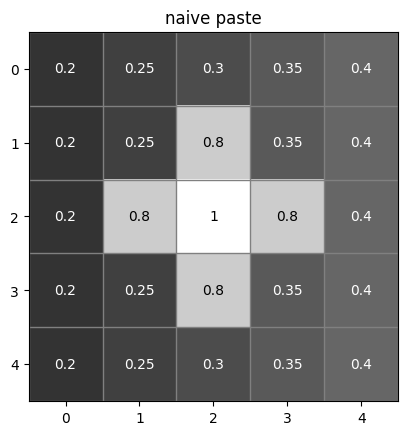

In [32]:
# run this cell to check your code
print('correct:', np.allclose(naive2[mask == 1], [0.8, 0.8, 1.0, 0.8, 0.8]) and np.allclose(naive2[mask == 0], tgt2[mask == 0]))

fig, ax = plt.subplots()
show_image(ax, naive2, 'naive paste')
plt.show()

### Step 2: compute b

For every masked pixel, b is:

**(second derivative of the source at that pixel, using all 4 neighbours)** + **(target value of every neighbour that is outside the mask)**

The source exists everywhere, so its second derivative always uses all 4 neighbours.
The target values are the fixed border, like the corners in Part 1.

Unknown 0 is done for you as an example. Look at the `unknown_index` plot to see which neighbours are inside the mask.

In [ ]:
b2 = np.zeros(5)

# Unknown 0 = pixel (1,2). Outside neighbours: (0,2), (1,1), (1,3). Inside: (2,2)
b2[0] = (4 * src2[1, 2] - src2[0, 2] - src2[2, 2] - src2[1, 1] - src2[1, 3]) + tgt2[0, 2] + tgt2[1, 1] + tgt2[1, 3]

# TODO: Unknown 1 = pixel (2,1). Outside neighbours: (1,1), (3,1), (2,0). Inside: (2,2)
...

# TODO: Unknown 2 = pixel (2,2), the centre. All 4 neighbours are inside
...

# TODO: Unknown 3 = pixel (2,3). Outside neighbours: (1,3), (3,3), (2,4). Inside: (2,2)
...

# TODO: Unknown 4 = pixel (3,2). Outside neighbours: (3,1), (3,3), (4,2). Inside: (2,2)
...

#### Solution
Try it yourself first, then open the hidden cell below.

In [33]:
#@title Solution
b2 = np.zeros(5)

# Unknown 0 = pixel (1,2). Outside neighbours: (0,2), (1,1), (1,3). Inside: (2,2)
b2[0] = (4 * src2[1, 2] - src2[0, 2] - src2[2, 2] - src2[1, 1] - src2[1, 3]) + tgt2[0, 2] + tgt2[1, 1] + tgt2[1, 3]

# Unknown 1 = pixel (2,1). Outside neighbours: (1,1), (3,1), (2,0). Inside: (2,2)
b2[1] = (4 * src2[2, 1] - src2[1, 1] - src2[3, 1] - src2[2, 0] - src2[2, 2]) + tgt2[1, 1] + tgt2[3, 1] + tgt2[2, 0]

# Unknown 2 = pixel (2,2), the centre. All 4 neighbours are inside
b2[2] = 4 * src2[2, 2] - src2[1, 2] - src2[3, 2] - src2[2, 1] - src2[2, 3]

# Unknown 3 = pixel (2,3). Outside neighbours: (1,3), (3,3), (2,4). Inside: (2,2)
b2[3] = (4 * src2[2, 3] - src2[1, 3] - src2[3, 3] - src2[2, 4] - src2[2, 2]) + tgt2[1, 3] + tgt2[3, 3] + tgt2[2, 4]

# Unknown 4 = pixel (3,2). Outside neighbours: (3,1), (3,3), (4,2). Inside: (2,2)
b2[4] = (4 * src2[3, 2] - src2[3, 1] - src2[3, 3] - src2[4, 2] - src2[2, 2]) + tgt2[3, 1] + tgt2[3, 3] + tgt2[4, 2]

In [34]:
# run this cell to check your code
print('b2 =', b2)
print('correct:', np.allclose(b2, [0.7, 0.5, 0.8, 0.9, 0.7]))

b2 = [0.7 0.5 0.8 0.9 0.7]
correct: True


### Step 3: build A

Row `k` is the equation for unknown `k`: `4` on the diagonal, and `-1` in the column of each neighbour that is **inside** the mask
(use `unknown_index` to find its column). Neighbours outside the mask are not in A: they went to b.

In [ ]:
A2 = np.zeros((5, 5))

# Unknown 0 = pixel (1,2): its only inside neighbour is (2,2) = unknown 2
A2[0, 0] = 4
A2[0, 2] = -1

# TODO: Unknown 1 = pixel (2,1)
...

# TODO: Unknown 2 = pixel (2,2), the centre
...

# TODO: Unknown 3 = pixel (2,3)
...

# TODO: Unknown 4 = pixel (3,2)
...

#### Solution
Try it yourself first, then open the hidden cell below.

In [35]:
#@title Solution
A2 = np.zeros((5, 5))

# Unknown 0 = pixel (1,2): its only inside neighbour is (2,2) = unknown 2
A2[0, 0] = 4
A2[0, 2] = -1

# Unknown 1 = pixel (2,1): only inside neighbour (2,2) = unknown 2
A2[1, 1] = 4
A2[1, 2] = -1

# Unknown 2 = pixel (2,2): all 4 neighbours are inside = unknowns 0, 1, 3, 4
A2[2, 2] = 4
A2[2, 0] = -1
A2[2, 1] = -1
A2[2, 3] = -1
A2[2, 4] = -1

# Unknown 3 = pixel (2,3): only inside neighbour (2,2) = unknown 2
A2[3, 3] = 4
A2[3, 2] = -1

# Unknown 4 = pixel (3,2): only inside neighbour (2,2) = unknown 2
A2[4, 4] = 4
A2[4, 2] = -1

[[ 4.  0. -1.  0.  0.]
 [ 0.  4. -1.  0.  0.]
 [-1. -1.  4. -1. -1.]
 [ 0.  0. -1.  4.  0.]
 [ 0.  0. -1.  0.  4.]]
correct: True


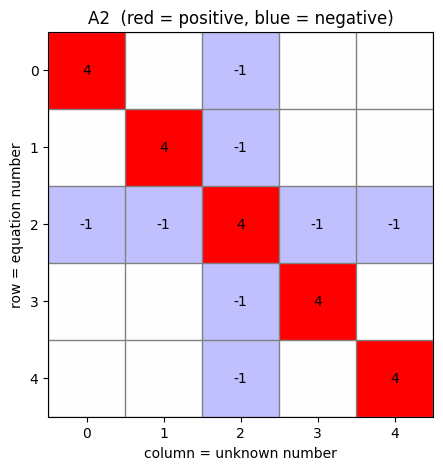

In [36]:
# run this cell to check your code
print(A2)
print('correct:', np.allclose(np.diag(A2), 4) and np.count_nonzero(A2) == 13
      and np.allclose(A2, A2.T) and np.allclose(A2.sum(axis=1), [3, 3, 0, 3, 3]))

fig, ax = plt.subplots(figsize=(5, 5))
show_image(ax, A2, 'A2  (red = positive, blue = negative)', vmin=-4, vmax=4, cmap='bwr', hide_zeros=True)
ax.set_xlabel('column = unknown number')
ax.set_ylabel('row = equation number')
plt.show()

### Step 4: solve and put the result back

Solve for the 5 unknowns, then put them into a copy of the target **inside the mask**.
(`blended2[mask == 1] = v2` fills the masked pixels row by row, the same order as `unknown_index`.)

In [ ]:
# TODO: solve A2 v2 = b2
v2 = ...

# TODO: put v2 into a copy of the target, inside the mask
blended2 = ...

#### Solution
Try it yourself first, then open the hidden cell below.

In [38]:
#@title Solution
v2 = np.linalg.solve(A2, b2)

blended2 = tgt2.copy()
blended2[mask == 1] = v2

v2 = [0.3  0.25 0.5  0.35 0.3 ]
correct: True


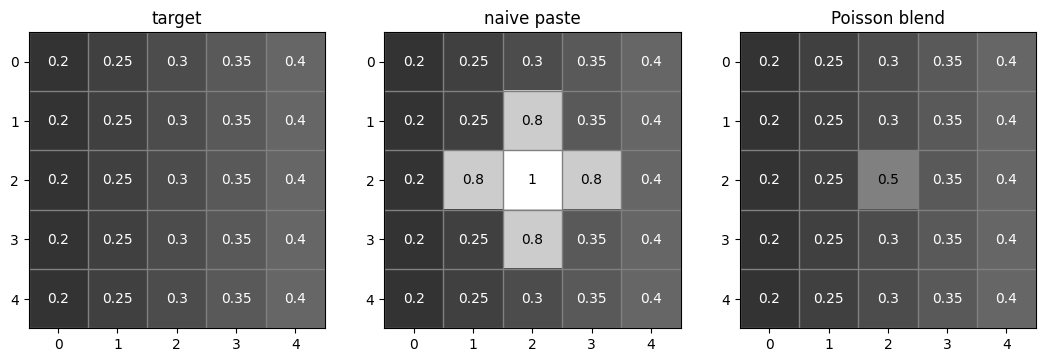

In [39]:
# run this cell to check your code
print('v2 =', v2)
print('correct:', np.allclose(v2, [0.3, 0.25, 0.5, 0.35, 0.3]))

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
show_image(axes[0], tgt2, 'target')
show_image(axes[1], naive2, 'naive paste')
show_image(axes[2], blended2, 'Poisson blend')
plt.show()

The bright plus disappeared into the target: its pixels took the target's values (0.3, 0.25, 0.35, 0.3).
Only the **detail** of the source was kept: the dot in the middle is still **0.2 brighter** than the pixels around it (0.5 vs 0.3),
just like in the source (1.0 vs 0.8).

# 5. The trap: where the guidance comes from

In the assignment, `align_target` returns the **target with the source already pasted inside the mask**,
like our naive paste. What happens if we take the second derivatives from that image instead of from the source?

Let's try it in 1D. This is the same code as Section 2, Step 2, but with `naive1` instead of `src1`:

result: [ 2.  3. 20. 24. 24. 20.  8.  9.]
same as the naive paste: True


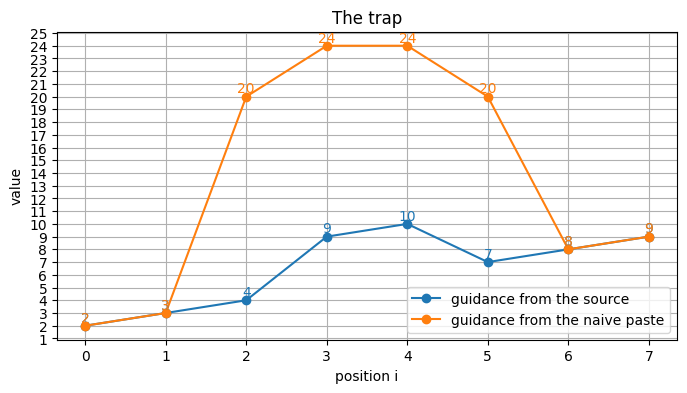

In [40]:
b_trap = np.zeros(4)

for i in range(2, 6):
    k = i - 2
    b_trap[k] = 2 * naive1[i] - naive1[i - 1] - naive1[i + 1]   # guidance from the naive paste!

b_trap[0] += tgt1[1]
b_trap[3] += tgt1[6]

trap1 = tgt1.copy()
trap1[2:6] = np.linalg.solve(A1, b_trap)

print('result:', trap1)
print('same as the naive paste:', np.allclose(trap1, naive1))

plot_1d([blended1, trap1], ['guidance from the source', 'guidance from the naive paste'], 'The trap')

We get the **naive paste back**: no blending at all.

**Why?** In the naive paste, position 1 is the target (3) and position 2 is the source (20).
So its "bend" at position 2 contains the jump itself (from 3 to 20), and the solver keeps that bend, so it rebuilds the jump.

**Lesson:** the second derivatives must come from the **source**, not from an image that already has the target around the patch.
Look at what `align_target` gives you before you use it.

# 6. Notes for the assignment

- **Colour:** solve each channel (B, G, R) separately. A is the same for all three; only b changes.
- **Big masks:** a real mask has thousands of pixels. Use the numbering from Section 3 and a sparse matrix.
- **Image border:** if the mask touches the border of the image, some neighbours don't exist.
- **Choose smooth regions** in both the source and the target. Blending works best there (the assignment PDF says so too).
- **Report** |Av − b| for every result.